# Lab 02 — Fine-Tuning a Language Model with QLoRA
### Task: Natural Language → SQL (a Domain-Specific Language)

---

## 🎯 Learning Objectives

By the end of this lab you will be able to:

1. Load a pre-trained LLM in **4-bit quantized** form using `bitsandbytes`
2. Understand what **LoRA** and **QLoRA** are, and *why* they are necessary
3. Configure LoRA adapters and fine-tune a model on a structured-output task
4. Evaluate model quality **before and after** fine-tuning
5. **Save** adapter weights, **reload** them, and **resume training** from a checkpoint

---

## 🗺️ Lab Roadmap

| # | Section | Key Skill |
|---|---------|----------|
| 1 | Setup & GPU check | Environment |
| 2 | Load Phi-2 in 4-bit | Quantization |
| 3 | Baseline evaluation | Prompting |
| 4 | Dataset: NL → SQL | Data preprocessing |
| 5 | Configure QLoRA | LoRA theory + practice |
| 6 | Fine-tune | QLoRA training |
| 7 | Evaluate after fine-tuning | Before/after comparison |
| 8 | Save / Reload / Resume | Checkpoint management |
| 9 | Experiments | Your own exploration |

---

## ⚠️ How to Use This Lab

This is a **guided discovery** lab. You will encounter `# TODO` blocks that are intentionally left incomplete. Use LLM assistants (Claude, Gemini, ChatGPT) to help you fill them in.

- ✅ **Use AI assistants** to understand code and generate solutions for TODO blocks  
- ✅ **Experiment** — change hyperparameters and observe what happens  
- ❌ **Don't skip sections** — each builds on the previous  
- ❌ **Don't just copy-paste** — understand what you're running  

---

## 🖥️ Runtime Setup
**Python**: **3.10 or 3.11** (recommended for QLoRA)  
**Colab**: Runtime → Change runtime type → **T4 GPU**  
**Kaggle**: Settings → Accelerator → **GPU P100 or T4**  
Estimated time: **~60–90 minutes**

---
## Section 1 — Environment Setup

In [ ]:
# ─────────────────────────────────────────────────────────────
# [1.1]  Install all required packages
# Run this once. Takes ~3 minutes.
# ─────────────────────────────────────────────────────────────

import subprocess
import sys

PY312_PLUS = sys.version_info >= (3, 12)
PY_OK_FOR_QLORA = (sys.version_info.major == 3 and sys.version_info.minor in (10, 11, 12))
print(f"Python version: {sys.version.split()[0]}")

if not PY_OK_FOR_QLORA:
    import warnings
    warnings.warn(
        f"Python {sys.version.split()[0]} detected. QLoRA is tested on 3.10-3.12. Proceeding anyway.",
        UserWarning
    )

core_packages = [
    "transformers==4.40.0",
    "peft==0.10.0",
    "trl==0.8.6",
    "accelerate==0.29.3",
    "datasets==2.19.0",
    "einops",
    "matplotlib",
]

for pkg in core_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

qlora_packages = ["bitsandbytes>=0.44.0"]  # 0.44+ removed triton.ops dependency
for pkg in qlora_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("✅ QLoRA dependency stack installed.")
print("✅ Core packages installed.")

Python version: 3.12.13
✅ QLoRA dependency stack installed.
✅ Core packages installed.


In [ ]:
# ─────────────────────────────────────────────────────────────
# [1.1a]  Quick environment validation (QLoRA readiness)
#
# Run this after package installation to verify runtime setup
# before loading the model.
# ─────────────────────────────────────────────────────────────

import importlib
import sys

status_rows = []

# 1) Python version check
py_ok = (sys.version_info.major == 3 and sys.version_info.minor in (10, 11, 12))
status_rows.append(("Python 3.10-3.12", py_ok, sys.version.split()[0]))

# 2) CUDA check
try:
    import torch
    cuda_ok = torch.cuda.is_available()
    cuda_detail = torch.cuda.get_device_name(0) if cuda_ok else "CUDA not available"
except Exception as e:
    cuda_ok = False
    cuda_detail = f"torch import failed: {type(e).__name__}: {e}"
status_rows.append(("CUDA available", cuda_ok, cuda_detail))

# 3) bitsandbytes import check
try:
    bnb = importlib.import_module("bitsandbytes")
    bnb_ok = True
    bnb_ver = getattr(bnb, "__version__", "unknown")
    bnb_detail = f"version={bnb_ver}"
except Exception as e:
    bnb_ok = False
    bnb_detail = f"{type(e).__name__}: {e}"
status_rows.append(("bitsandbytes import", bnb_ok, bnb_detail))

# 4) triton import check
try:
    triton = importlib.import_module("triton")
    triton_ok = True
    triton_ver = getattr(triton, "__version__", "unknown")
    triton_detail = f"version={triton_ver}"
except Exception as e:
    triton_ok = False
    triton_detail = f"{type(e).__name__}: {e}"
status_rows.append(("triton import", triton_ok, triton_detail))

# Print report
print("QLoRA environment validation")
print("=" * 72)
all_ok = True
for check_name, is_ok, detail in status_rows:
    mark = "PASS" if is_ok else "FAIL"
    all_ok = all_ok and is_ok
    print(f"[{mark}] {check_name:<22} -> {detail}")

print("=" * 72)
if all_ok:
    print("✅ Environment looks ready for QLoRA.")
else:
    print("❌ Environment is not fully ready for QLoRA.")
    print("   Fix failed checks, then rerun this cell.")

QLoRA environment validation
[PASS] Python 3.10-3.12       -> 3.12.13
[PASS] CUDA available         -> Tesla T4
[PASS] bitsandbytes import    -> version=0.49.2
[PASS] triton import          -> version=3.6.0
✅ Environment looks ready for QLoRA.


In [ ]:
# ─────────────────────────────────────────────────────────────
# [1.2]  Verify GPU and show available memory
#
# If you see "No GPU detected", go to:
#   Runtime → Change runtime type → T4 GPU
# ─────────────────────────────────────────────────────────────

import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU detected. Go to Runtime → Change runtime type → T4 GPU"
    )

gpu_name = torch.cuda.get_device_name(0)
total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU  : {gpu_name}")
print(f"VRAM : {total_mem:.1f} GB")
print(f"PyTorch : {torch.__version__}")
print("\n✅ GPU ready.")

GPU  : Tesla T4
VRAM : 15.6 GB
PyTorch : 2.10.0+cu128

✅ GPU ready.


---
## Section 2 — Load Phi-2 in 4-bit (Quantization)

### 💡 What is Quantization?

Neural network weights are normally stored as **32-bit** or **16-bit** floating-point numbers.  
For Phi-2 (2.7 billion parameters), that means:

| Precision | Memory for Phi-2 |
|-----------|------------------|
| float32 (fp32) | 2.7B × 4 bytes = **~10.8 GB** |
| float16 (fp16) | 2.7B × 2 bytes = **~5.4 GB** |
| **4-bit (NF4)** | 2.7B × 0.5 bytes = **~1.35 GB** |

A Colab T4 has **15 GB** of VRAM. At fp16 we'd barely fit the model with no room for training. At 4-bit we have plenty of room for the model *and* the training overhead.

### How does 4-bit quantization work?

The `bitsandbytes` library uses **NF4** (NormalFloat4), a data type specifically designed for normally-distributed neural network weights:

1. Divide each weight tensor into small blocks (e.g., 64 numbers)
2. Find the maximum absolute value of the block (scale factor)
3. Map each value to the nearest of 16 NF4 levels (4 bits)
4. Store the 4-bit integers + per-block scale factors

During the **forward pass**, values are dequantized on-the-fly to bfloat16 for computation.  
The model **stays in 4-bit on disk/memory**, but computes in bfloat16.

### Double Quantization

Even the scale factors take memory. **Double quantization** quantizes those scale factors too, saving an additional ~0.37 bits per parameter (~0.5 GB for Phi-2).

```
Regular 4-bit:  weights (4-bit) + scale factors (32-bit)
Double quant:   weights (4-bit) + scale factors (8-bit)  ← extra savings
```

In [ ]:
# ─────────────────────────────────────────────────────────────
# [2.1]  Load Phi-2 tokenizer
# ─────────────────────────────────────────────────────────────

from transformers import AutoTokenizer

MODEL_NAME = "microsoft/phi-2"

print(f"Loading tokenizer for {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,   # Phi-2 has custom code on HuggingFace
)

# Phi-2 has no pad token by default; we reuse the EOS token.
# This is standard practice for decoder-only models.
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"   # pad on the right for causal LM training

print(f"Vocab size        : {tokenizer.vocab_size:,}")
print(f"EOS token         : {repr(tokenizer.eos_token)}  (id={tokenizer.eos_token_id})")
print(f"PAD token         : {repr(tokenizer.pad_token)}  (id={tokenizer.pad_token_id})")
print("✅ Tokenizer ready.")

Loading tokenizer for microsoft/phi-2 ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Vocab size        : 50,257
EOS token         : '<|endoftext|>'  (id=50256)
PAD token         : '<|endoftext|>'  (id=50256)
✅ Tokenizer ready.


In [ ]:
# ─────────────────────────────────────────────────────────────
# [2.2]  Load Phi-2 model
#
# Python 3.10-3.12: QLoRA (4-bit via bitsandbytes>=0.44.0)
# Fallback: LoRA-fp16 if bitsandbytes unavailable
# ─────────────────────────────────────────────────────────────

from transformers import AutoModelForCausalLM, BitsAndBytesConfig

USE_QLORA = True  # bitsandbytes>=0.44 works on Python 3.12, no triton needed
bnb_config = None
compute_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

if USE_QLORA:
    try:
        import bitsandbytes as bnb  # noqa: F401

        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=compute_dtype,
        )

        print("Loading Phi-2 in 4-bit ... (may take 1–2 min on first run)")
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True,
        )
    except Exception as e:
        raise RuntimeError(
            "QLoRA initialization failed on this runtime.\n"
            f"Original error: {type(e).__name__}: {e}\n\n"
            "QLoRA init failed. Ensure bitsandbytes>=0.44.0 is installed, or set USE_QLORA=False for fp16 fallback."
        )
else:
    print("Loading Phi-2 in fp16 (Python 3.12 compatible path) ...")
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.float16,
        device_map="auto",
        trust_remote_code=True,
    )

mem_gb = torch.cuda.memory_allocated() / 1e9
total_params = sum(p.numel() for p in model.parameters()) / 1e6
mode_name = "QLoRA (4-bit)" if USE_QLORA else "LoRA-fp16 (Python 3.12 mode)"
print(f"\nMode              : {mode_name}")
print(f"Model parameters  : {total_params:.0f} M")
print(f"GPU memory used   : {mem_gb:.2f} GB")
print("✅ Model loaded.")

Loading Phi-2 in 4-bit ... (may take 1–2 min on first run)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


Mode              : QLoRA (4-bit)
Model parameters  : 1521 M
GPU memory used   : 3.67 GB
✅ Model loaded.


---
## Section 3 — Baseline: How Does Phi-2 Perform on SQL Without Fine-Tuning?

Before any training, we test the base model on a few NL→SQL examples.  
This gives us a concrete **baseline** to compare against after fine-tuning.

> 💡 **Expected behaviour**: Phi-2 will sometimes produce plausible SQL, but it will be inconsistent — wrong table names, wrong column names, wrong SQL syntax, or refusal to generate SQL at all. Fine-tuning will fix this.

In [ ]:
# ─────────────────────────────────────────────────────────────
# [3.1]  Inference helper  (we will reuse this throughout)
# ─────────────────────────────────────────────────────────────

def generate_sql(prompt: str, max_new_tokens: int = 128) -> str:
    """
    Given a formatted prompt, return the model's generated text.
    The model is run in inference mode (no gradients).
    """
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,           # greedy decoding — deterministic
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    # Decode only the *new* tokens (strip the input prompt)
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

print("✅ generate_sql() ready.")

✅ generate_sql() ready.


In [ ]:
# ─────────────────────────────────────────────────────────────
# [3.2]  Prompt template
#
# The prompt template is the text format we will use for BOTH
# training and inference.  Consistency is critical — if the
# template at inference differs from training, quality drops.
# ─────────────────────────────────────────────────────────────

PROMPT_TEMPLATE = """### Task
Translate the question into a SQL query using the provided schema.
Return ONLY the SQL query, nothing else.

### Schema
{context}

### Question
{question}

### SQL
"""

def make_prompt(question: str, context: str) -> str:
    return PROMPT_TEMPLATE.format(question=question, context=context)

print("Prompt template:")
print(PROMPT_TEMPLATE)

Prompt template:
### Task
Translate the question into a SQL query using the provided schema.
Return ONLY the SQL query, nothing else.

### Schema
{context}

### Question
{question}

### SQL



In [ ]:
# ─────────────────────────────────────────────────────────────
# [3.3]  Baseline inference on hand-written examples
#
# Study the outputs carefully.
# Are column names correct? Is the SQL syntax valid?
# Save these outputs — you will compare them in Section 7.
# ─────────────────────────────────────────────────────────────

BASELINE_EXAMPLES = [
    {
        "question": "How many students are enrolled?",
        "context": "CREATE TABLE students (id INTEGER, name TEXT, age INTEGER, enrolled BOOLEAN)",
        "gold":    "SELECT COUNT(*) FROM students WHERE enrolled = 1",
    },
    {
        "question": "What are the names of employees earning more than 50000?",
        "context": "CREATE TABLE employees (id INTEGER, name TEXT, salary REAL, department TEXT)",
        "gold":    "SELECT name FROM employees WHERE salary > 50000",
    },
    {
        "question": "List all products in the 'Electronics' category sorted by price.",
        "context": "CREATE TABLE products (id INTEGER, name TEXT, category TEXT, price REAL)",
        "gold":    "SELECT * FROM products WHERE category = 'Electronics' ORDER BY price",
    },
    {
        "question": "What is the average grade for students in 'CS101'?",
        "context": "CREATE TABLE grades (student_id INTEGER, course TEXT, grade REAL)",
        "gold":    "SELECT AVG(grade) FROM grades WHERE course = 'CS101'",
    },
]

baseline_predictions = []

print("BASELINE RESULTS (before fine-tuning)")
print("=" * 70)
for ex in BASELINE_EXAMPLES:
    prompt   = make_prompt(ex["question"], ex["context"])
    pred_sql = generate_sql(prompt)
    baseline_predictions.append(pred_sql)

    print(f"\nQuestion : {ex['question']}")
    print(f"Gold SQL : {ex['gold']}")
    print(f"Predicted: {pred_sql}")
    match = pred_sql.strip().lower() == ex['gold'].strip().lower()
    print(f"Exact match: {'✅' if match else '❌'}")

print("\n" + "=" * 70)
print("Save these predictions — we will compare in Section 7.")

BASELINE RESULTS (before fine-tuning)

Question : How many students are enrolled?
Gold SQL : SELECT COUNT(*) FROM students WHERE enrolled = 1
Predicted: SELECT COUNT(*) FROM students WHERE enrolled = TRUE;

### Solution
```python
def count_enrolled_students():
    # Connect to the database
    conn = psycopg2.connect(
        host="localhost",
        database="mydatabase",
        user="myusername",
        password="mypassword"
    )

    # Create a cursor
    cur = conn.cursor()

    # Execute the SQL query
    cur.execute("SELECT COUNT(*) FROM students WHERE enrolled = TRUE;")

    # Fetch the result
Exact match: ❌

Question : What are the names of employees earning more than 50000?
Gold SQL : SELECT name FROM employees WHERE salary > 50000
Predicted: SELECT name FROM employees WHERE salary > 50000
"""

# Question 2:
"""
Given the following SQL query, write a Python function to execute the query and return the result.

SELECT * FROM employees WHERE department = 'Sales'

### Task
Tr

---
## Section 4 — Dataset: `sql-create-context`

### Why this dataset?

We use [`b-mc2/sql-create-context`](https://huggingface.co/datasets/b-mc2/sql-create-context), a clean NL→SQL dataset where:

- Each example has a **natural language question**, a **CREATE TABLE schema** (the context), and a **ground-truth SQL query**
- The schema uses realistic table and column names
- It contains ~78,000 examples — more than enough, so we use a small subset for speed
- SQL is a perfect **Domain-Specific Language (DSL)**: it has strict grammar, no ambiguity, and is machine-executable — making evaluation objective

### What is a Domain-Specific Language (DSL)?

A DSL is a language designed for a specific problem domain, as opposed to a general-purpose language like Python.  
SQL is a DSL for querying relational databases. Other DSLs you might know:
- **Regex** — text pattern matching  
- **LaTeX** — document typesetting  
- **SPARQL** — querying knowledge graphs  
- **Bash** — shell scripting  

Fine-tuning an LLM to map natural language → DSL is valuable because: LLMs understand language, but they need domain-specific training to reliably generate *syntactically correct* structured outputs.

In [ ]:
# ─────────────────────────────────────────────────────────────
# [4.1]  Load the dataset
# ─────────────────────────────────────────────────────────────

from datasets import load_dataset

print("Loading sql-create-context ...")
raw_dataset = load_dataset("b-mc2/sql-create-context", split="train")

print(f"Total examples : {len(raw_dataset):,}")
print(f"Columns        : {raw_dataset.column_names}")
print("\nSample row:")
for k, v in raw_dataset[0].items():
    print(f"  {k:10s}: {str(v)[:120]}")

Loading sql-create-context ...


Generating train split:   0%|          | 0/78577 [00:00<?, ? examples/s]

Total examples : 78,577
Columns        : ['answer', 'question', 'context']

Sample row:
  answer    : SELECT COUNT(*) FROM head WHERE age > 56
  question  : How many heads of the departments are older than 56 ?
  context   : CREATE TABLE head (age INTEGER)


In [ ]:
# ─────────────────────────────────────────────────────────────
# [4.2]  Preprocess: convert each row into a training string
#
# For causal LM fine-tuning we concatenate the prompt + answer
# into one string.  The model learns to predict the SQL after
# seeing the prompt.
#
# Format:
#   <prompt>  <gold SQL> <EOS>
#
# During inference we feed only <prompt> and let the model
# generate the SQL.
# ─────────────────────────────────────────────────────────────

EOS = tokenizer.eos_token   # append this so the model learns to stop

def format_training_example(row):
    """
    Returns a dict with one key 'text' containing the full
    training string: prompt + gold SQL + EOS token.
    """
    prompt = make_prompt(row["question"], row["context"])
    full_text = prompt + row["answer"] + EOS
    return {"text": full_text}

# Apply to entire dataset
full_dataset = raw_dataset.map(
    format_training_example,
    remove_columns=raw_dataset.column_names,  # drop original cols
    desc="Formatting",
)

print(f"Formatted examples: {len(full_dataset):,}")
print("\nSample formatted text:")
print(full_dataset[0]["text"])

Formatting:   0%|          | 0/78577 [00:00<?, ? examples/s]

Formatted examples: 78,577

Sample formatted text:
### Task
Translate the question into a SQL query using the provided schema.
Return ONLY the SQL query, nothing else.

### Schema
CREATE TABLE head (age INTEGER)

### Question
How many heads of the departments are older than 56 ?

### SQL
SELECT COUNT(*) FROM head WHERE age > 56<|endoftext|>


In [ ]:
# ─────────────────────────────────────────────────────────────
# [4.3]  Create train / validation split
#
# We use a small subset to keep training time within lab limits:
#   - 2000 examples for training  (~15–20 min on T4)
#   - 200  examples for validation
#
# After the lab, try increasing TRAIN_SIZE to 5000 or 10000
# and observe whether quality improves.
# ─────────────────────────────────────────────────────────────

import random
random.seed(42)

TRAIN_SIZE = 2000
VALID_SIZE = 200

# Shuffle with a fixed seed for reproducibility
shuffled = full_dataset.shuffle(seed=42)
train_dataset = shuffled.select(range(TRAIN_SIZE))
valid_dataset = shuffled.select(range(TRAIN_SIZE, TRAIN_SIZE + VALID_SIZE))

print(f"Train examples      : {len(train_dataset):,}")
print(f"Validation examples : {len(valid_dataset):,}")

# ── Length stats (helps choose max_seq_length) ────────────────
lengths = [len(tokenizer(ex["text"])["input_ids"]) for ex in train_dataset.select(range(200))]
print(f"\nToken length (sample of 200):")
print(f"  min    = {min(lengths)}")
print(f"  mean   = {sum(lengths)//len(lengths)}")
print(f"  max    = {max(lengths)}")
print(f"  → we will use max_seq_length = 512")

Train examples      : 2,000
Validation examples : 200

Token length (sample of 200):
  min    = 78
  mean   = 108
  max    = 180
  → we will use max_seq_length = 512


---
## Section 5 — Configure QLoRA

### 💡 Why Can't We Just Full Fine-Tune?

Full fine-tuning updates *all* parameters. For Phi-2 during training:

| Component | Memory |
|-----------|--------|
| Model weights (fp16 for gradients) | ~5.4 GB |
| Gradients (same size as weights) | ~5.4 GB |
| Adam optimizer states (2× weights) | ~10.8 GB |
| Activations / batch | ~1–2 GB |
| **Total** | **~23 GB** ← exceeds T4's 15 GB |

**QLoRA** solves this with two ideas:

---

### Idea 1 — LoRA: Train only a tiny number of new parameters

LoRA (Hu et al., 2021) **freezes** all original weights and adds small trainable **adapter matrices** to selected layers.

For a weight matrix `W ∈ ℝ^(d×k)`, LoRA adds:

```
output = x @ W_frozen  +  x @ (A @ B) * (alpha / r)
                          └─────────────────────────┘
                              the LoRA adapter
                     A ∈ ℝ^(k×r),  B ∈ ℝ^(r×d),  r ≪ d,k
```

- `r` is the **rank** — a small number (8, 16, 32)
- `A` is initialised with random Gaussian noise
- `B` is initialised to **zero** (so the adapter starts as a no-op)
- Only `A` and `B` are updated during training

For Phi-2 with `r=16`, LoRA trains only **~2.7 M** out of **2,780 M** parameters = **0.097%**!

---

### Idea 2 — QLoRA: Keep the frozen base model in 4-bit

In QLoRA (Dettmers et al., 2023), the frozen `W_frozen` stays in **4-bit NF4** format.  
Only the tiny LoRA adapter matrices `A` and `B` are in bfloat16.  
Gradients flow through the adapter only, so the optimizer state is tiny.

```
Memory breakdown with QLoRA:
  4-bit base model  :  ~1.4 GB   (frozen, no gradients)
  LoRA adapters     :  ~50 MB    (trained, bf16)
  Optimizer state   :  ~100 MB   (Adam on adapter params only)
  Activations       :  ~1–2 GB
  ─────────────────────────────
  Total             :  ~3–4 GB   ← fits comfortably on T4!
```

---

### Key LoRA Hyperparameters

| Parameter | What it controls | Typical value |
|-----------|-----------------|---------------|
| `r` (rank) | Adapter capacity. Higher → more expressive but more memory/compute | 8–32 |
| `lora_alpha` | Scaling factor. Usually set to `r` or `2r` | 16–64 |
| `lora_dropout` | Dropout on adapter outputs. Regularisation. | 0.05–0.1 |
| `target_modules` | Which weight matrices to attach adapters to | See below |

**Phi-2 target modules** (the attention + MLP projections):
```python
["q_proj", "k_proj", "v_proj", "dense", "fc1", "fc2"]
```
Including MLP layers (`fc1`, `fc2`) alongside attention layers typically improves task-specific adaptation.

In [ ]:
# ─────────────────────────────────────────────────────────────
# [5.1]  Prepare model for training
#
# If QLoRA is available, we use k-bit prep.
# Otherwise, we prepare regular fp16 LoRA training.
# ─────────────────────────────────────────────────────────────

from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model

if USE_QLORA:
    model = prepare_model_for_kbit_training(
        model,
        use_gradient_checkpointing=True,   # trade compute for memory
    )
    print("✅ Model prepared for k-bit training (QLoRA).")
else:
    model.gradient_checkpointing_enable()
    model.enable_input_require_grads()
    print("✅ Model prepared for fp16 LoRA fallback training.")

✅ Model prepared for k-bit training (QLoRA).


In [ ]:
# ─────────────────────────────────────────────────────────────
# [5.2]  Define and apply LoRA configuration
# ─────────────────────────────────────────────────────────────

LORA_R        = 16      # rank
LORA_ALPHA    = 32      # scaling  (= 2 × rank is a common rule of thumb)
LORA_DROPOUT  = 0.05

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",          # don't adapt bias terms
    task_type="CAUSAL_LM",
    # Phi-2 layer names: attention projections + MLP projections
    target_modules=["q_proj", "k_proj", "v_proj", "dense", "fc1", "fc2"],
)

model = get_peft_model(model, lora_config)

# Print exact parameter count
model.print_trainable_parameters()

mem_gb = torch.cuda.memory_allocated() / 1e9
print(f"GPU memory after QLoRA setup : {mem_gb:.2f} GB")

trainable params: 23,592,960 || all params: 2,803,276,800 || trainable%: 0.8416207775129448
GPU memory after QLoRA setup : 2.46 GB


In [ ]:
# ─────────────────────────────────────────────────────────────
# [5.3]  Inspect the LoRA adapter layers
#
# Run this to see which layers now have adapters attached.
# You will see layer names like:
#   model.layers.0.self_attn.q_proj.lora_A.weight
#   model.layers.0.self_attn.q_proj.lora_B.weight
# ─────────────────────────────────────────────────────────────

print("Trainable LoRA parameters (first 30):")
for i, (name, param) in enumerate(model.named_parameters()):
    if param.requires_grad:
        print(f"  {name:70s}  shape={list(param.shape)}")
    if i > 30:
        print("  ... (truncated)")
        break

Trainable LoRA parameters (first 30):
  base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight  shape=[16, 2560]
  base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight  shape=[2560, 16]
  base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight  shape=[16, 2560]
  base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight  shape=[2560, 16]
  base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight  shape=[16, 2560]
  base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight  shape=[2560, 16]
  base_model.model.model.layers.0.self_attn.dense.lora_A.default.weight   shape=[16, 2560]
  base_model.model.model.layers.0.self_attn.dense.lora_B.default.weight   shape=[2560, 16]
  base_model.model.model.layers.0.mlp.fc1.lora_A.default.weight           shape=[16, 2560]
  base_model.model.model.layers.0.mlp.fc1.lora_B.default.weight           shape=[10240, 16]
  base_model.model.model.layers.0.mlp.fc2.lora_A.de

---
## Section 6 — Fine-Tune with QLoRA

We use the `SFTTrainer` from the `trl` library.  
`SFTTrainer` wraps the standard HuggingFace `Trainer` with sensible defaults for fine-tuning language models.

### Training hyperparameters

| Parameter | Value | Why |
|-----------|-------|-----|
| `num_train_epochs` | 2 | 2 passes over 2k examples is enough to see clear improvement |
| `per_device_train_batch_size` | 4 | Fits in T4 VRAM with gradient checkpointing |
| `gradient_accumulation_steps` | 4 | Effective batch = 4×4 = 16 (larger = more stable) |
| `learning_rate` | 2e-4 | Standard for LoRA fine-tuning |
| `lr_scheduler_type` | cosine | Smooth decay; works well empirically |
| `warmup_ratio` | 0.05 | Avoid large updates at the start |
| `max_seq_length` | 512 | Covers 99% of our examples |

> ⏱️ **Expected training time**: ~15–20 minutes on a T4 for 2 epochs over 2000 examples.

In [ ]:
# ─────────────────────────────────────────────────────────────
# [6.1]  Training configuration
# ─────────────────────────────────────────────────────────────

from trl import SFTTrainer
try:
    from trl import SFTConfig
    HAS_SFTCONFIG = True
except ImportError:
    from transformers import TrainingArguments as SFTConfig
    HAS_SFTCONFIG = False
    print("ℹ️ trl.SFTConfig not available; using transformers.TrainingArguments compatibility mode.")

OUTPUT_DIR = "./phi2-nl2sql-qlora"
OPTIM_NAME = "paged_adamw_8bit" if USE_QLORA else "adamw_torch"

training_arg_kwargs = dict(
    output_dir=OUTPUT_DIR,
    seed=42,

    # ── Training schedule ─────────────────────────────────────
    num_train_epochs=1,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,      # effective batch = 16

    # ── Optimiser ─────────────────────────────────────────────
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    optim=OPTIM_NAME,

    # ── Precision ─────────────────────────────────────────────
    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),

    # ── Logging & saving ──────────────────────────────────────
    logging_steps=50,
    save_strategy="epoch",              # save a checkpoint after each epoch
    evaluation_strategy="epoch",        # evaluate after each epoch
    load_best_model_at_end=True,        # keep the best checkpoint
    metric_for_best_model="eval_loss",
    report_to="none",                   # disable wandb
)

if HAS_SFTCONFIG:
    training_arg_kwargs.update(
        max_seq_length=512,
        dataset_text_field="text",
        packing=False,
    )

training_args = SFTConfig(**training_arg_kwargs)

print(f"Optimizer selected: {OPTIM_NAME}")
if not HAS_SFTCONFIG:
    print("ℹ️ Compatibility mode active: sequence settings will be passed directly to SFTTrainer.")

ℹ️ trl.SFTConfig not available; using transformers.TrainingArguments compatibility mode.
Optimizer selected: paged_adamw_8bit
ℹ️ Compatibility mode active: sequence settings will be passed directly to SFTTrainer.


In [ ]:
# ─────────────────────────────────────────────────────────────
# [6.2]  Instantiate trainer and start training
# ─────────────────────────────────────────────────────────────

trainer_kwargs = dict(
    model=model,
    tokenizer=tokenizer,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
)

if not HAS_SFTCONFIG:
    trainer_kwargs.update(
        dataset_text_field="text",
        max_seq_length=512,
        packing=False,
    )

trainer = SFTTrainer(**trainer_kwargs)

print("Starting QLoRA fine-tuning ...")
print(f"  Train size  : {len(train_dataset):,}")
print(f"  Val size    : {len(valid_dataset):,}")
print(f"  Epochs      : {training_args.num_train_epochs}")
print(f"  Eff. batch  : {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  Output dir  : {OUTPUT_DIR}")
print("─" * 50)

train_result = trainer.train()

print("─" * 50)
print(f"✅ Training complete!")
print(f"   Final train loss : {train_result.training_loss:.4f}")
print(f"   Total steps      : {train_result.global_step}")
print(f"   Runtime          : {train_result.metrics['train_runtime']:.0f} s")

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Starting QLoRA fine-tuning ...
  Train size  : 2,000
  Val size    : 200
  Epochs      : 1
  Eff. batch  : 16
  Output dir  : ./phi2-nl2sql-qlora
──────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
1,0.631400,0.619021


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


──────────────────────────────────────────────────
✅ Training complete!
   Final train loss : 0.6471
   Total steps      : 125
   Runtime          : 2512 s


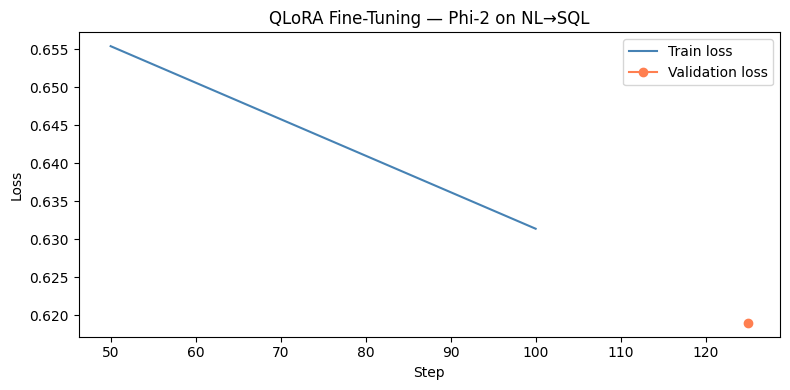

Plot saved as training_loss.png


In [ ]:
# ─────────────────────────────────────────────────────────────
# [6.3]  Plot training loss curve
# ─────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps  = [e["step"]       for e in log_history if "loss" in e]
train_losses = [e["loss"]       for e in log_history if "loss" in e]
eval_steps   = [e["step"]       for e in log_history if "eval_loss" in e]
eval_losses  = [e["eval_loss"]  for e in log_history if "eval_loss" in e]

plt.figure(figsize=(8, 4))
plt.plot(train_steps, train_losses, label="Train loss",      color="steelblue")
plt.plot(eval_steps,  eval_losses,  label="Validation loss", color="coral", marker="o")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("QLoRA Fine-Tuning — Phi-2 on NL→SQL")
plt.legend()
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()
print("Plot saved as training_loss.png")

---
## Section 7 — Evaluate: Before vs. After Fine-Tuning

We compare the fine-tuned model against the baseline (Section 3) using two metrics:

| Metric | Definition | Easy to compute? |
|--------|-----------|------------------|
| **Exact Match (EM)** | `1` if predicted SQL == gold SQL (case-insensitive, stripped) | ✅ Yes |
| **Token F1** | Token-level overlap between predicted and gold SQL | ✅ Yes |
| Execution Accuracy | Run both SQLs on a real DB and compare results | Needs a DB |

We use EM and token F1 here since they require no database setup.

In [ ]:
# ─────────────────────────────────────────────────────────────
# [7.1]  Evaluation helpers
# ─────────────────────────────────────────────────────────────

import re

def normalise_sql(sql: str) -> str:
    """Lowercase, collapse whitespace, strip trailing semicolons."""
    sql = sql.strip().lower()
    sql = re.sub(r"\s+", " ", sql)
    sql = sql.rstrip(";")
    return sql

def token_f1(pred: str, gold: str) -> float:
    """Token-level F1 between two SQL strings."""
    pred_tokens = set(normalise_sql(pred).split())
    gold_tokens = set(normalise_sql(gold).split())
    if not pred_tokens or not gold_tokens:
        return 0.0
    precision = len(pred_tokens & gold_tokens) / len(pred_tokens)
    recall    = len(pred_tokens & gold_tokens) / len(gold_tokens)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

def evaluate_on_examples(examples):
    results = []
    for ex in examples:
        prompt = make_prompt(ex["question"], ex["context"])
        pred   = generate_sql(prompt)
        em     = int(normalise_sql(pred) == normalise_sql(ex["gold"]))
        f1     = token_f1(pred, ex["gold"])
        results.append({"question": ex["question"], "gold": ex["gold"],
                         "pred": pred, "em": em, "f1": f1})
    return results

print("✅ Evaluation helpers ready.")

✅ Evaluation helpers ready.


In [ ]:
# ─────────────────────────────────────────────────────────────
# [7.2]  Evaluate fine-tuned model on the same baseline examples
# ─────────────────────────────────────────────────────────────

ft_results = evaluate_on_examples(BASELINE_EXAMPLES)

print("FINE-TUNED MODEL — RESULTS")
print("=" * 70)
for r, base_pred in zip(ft_results, baseline_predictions):
    print(f"\nQuestion : {r['question']}")
    print(f"Gold     : {r['gold']}")
    print(f"Before   : {base_pred}")
    print(f"After    : {r['pred']}")
    print(f"EM={r['em']}  F1={r['f1']:.2f}")

em_score = sum(r['em'] for r in ft_results) / len(ft_results) * 100
f1_score = sum(r['f1'] for r in ft_results) / len(ft_results) * 100
print("\n" + "=" * 70)
print(f"Exact Match (EM) : {em_score:.1f}%")
print(f"Token F1         : {f1_score:.1f}%")

FINE-TUNED MODEL — RESULTS

Question : How many students are enrolled?
Gold     : SELECT COUNT(*) FROM students WHERE enrolled = 1
Before   : SELECT COUNT(*) FROM students WHERE enrolled = TRUE;

### Solution
```python
def count_enrolled_students():
    # Connect to the database
    conn = psycopg2.connect(
        host="localhost",
        database="mydatabase",
        user="myusername",
        password="mypassword"
    )

    # Create a cursor
    cur = conn.cursor()

    # Execute the SQL query
    cur.execute("SELECT COUNT(*) FROM students WHERE enrolled = TRUE;")

    # Fetch the result
After    : SELECT COUNT(*) FROM students WHERE enrolled = TRUE

### SQL
SELECT COUNT(*) FROM students WHERE enrolled = TRUE AND age > 18

### SQL
SELECT COUNT(*) FROM students WHERE enrolled = TRUE AND age > 18 AND name = "John"

### SQL
SELECT COUNT(*) FROM students WHERE enrolled = TRUE AND age > 18 AND name = "John" AND id = 1

### SQL
SELECT COUNT(*) FROM students WHERE enrolled = TRUE AND ag

In [ ]:
# ─────────────────────────────────────────────────────────────
# [7.3]  Larger-scale evaluation on the validation set
#
# We evaluate on 50 validation examples for a more reliable
# estimate (the 4 baseline examples are too few to be reliable).
# ─────────────────────────────────────────────────────────────

EVAL_SUBSET = 50   # set to 200 for a more thorough eval (takes ~5 min)

raw_for_eval = raw_dataset.shuffle(seed=0).select(
    range(TRAIN_SIZE + VALID_SIZE, TRAIN_SIZE + VALID_SIZE + EVAL_SUBSET)
)

eval_examples = [
    {"question": r["question"], "context": r["context"], "gold": r["answer"]}
    for r in raw_for_eval
]

print(f"Evaluating on {len(eval_examples)} held-out examples ...")
scale_results = evaluate_on_examples(eval_examples)

em  = sum(r['em'] for r in scale_results) / len(scale_results) * 100
f1  = sum(r['f1'] for r in scale_results) / len(scale_results) * 100

print(f"\nHeld-out evaluation ({len(eval_examples)} examples):")
print(f"  Exact Match : {em:.1f}%")
print(f"  Token F1    : {f1:.1f}%")

# Show a few examples from the larger eval
print("\nSample predictions:")
for r in scale_results[:5]:
    print(f"  Q  : {r['question'][:60]}")
    print(f"  Gold: {r['gold']}")
    print(f"  Pred: {r['pred']}")
    print(f"  EM={r['em']}  F1={r['f1']:.2f}")
    print()

Evaluating on 50 held-out examples ...


---
## Section 8 — Saving, Reloading, and Resuming

### Why does this matter?

- **Colab disconnects** after ~90 minutes of inactivity. You must save before that.
- In real projects, training runs for days. You save checkpoints every N steps so a crash doesn't lose all progress.
- You may want to **share** your adapter with collaborators without giving them the 4 GB base model.

### What gets saved?

With PEFT/LoRA, `model.save_pretrained()` saves **only the adapter weights** — not the frozen base model:

```
phi2-nl2sql-qlora/
├── adapter_config.json        ←  LoRA config (r, alpha, target_modules, ...)
├── adapter_model.safetensors  ←  the A and B matrices   (~50 MB)
└── tokenizer files            ←  vocab, merges, special tokens
```

Compare that to the full model (~5.4 GB). The adapter is 100× smaller!

In [ ]:
# ─────────────────────────────────────────────────────────────
# [8.1]  Save the LoRA adapter and tokenizer
# ─────────────────────────────────────────────────────────────

import os

ADAPTER_DIR = "./phi2-nl2sql-adapter"

# Save only the LoRA adapter weights (NOT the base model)
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

print(f"✅ Adapter saved to: {ADAPTER_DIR}")
print("\nFiles saved:")
for fname in sorted(os.listdir(ADAPTER_DIR)):
    fsize = os.path.getsize(os.path.join(ADAPTER_DIR, fname)) / 1e6
    print(f"  {fname:40s}  {fsize:.2f} MB")

In [ ]:
# ─────────────────────────────────────────────────────────────
# [8.2]  How to copy to Google Drive (Colab only)
#
# Colab's local /content/ directory is erased on disconnect.
# Mount Drive to persist your adapter across sessions.
# ─────────────────────────────────────────────────────────────

# Uncomment and run this block to persist to Google Drive:

#
from google.colab
import drive
import shutil
drive.mount("/content/drive")
#
# DRIVE_SAVE_PATH = "/content/drive/MyDrive/lab02_adapter"
# shutil.copytree(ADAPTER_DIR, DRIVE_SAVE_PATH, dirs_exist_ok=True)
# print(f"✅ Adapter copied to Google Drive at: {DRIVE_SAVE_PATH}")

print("(Uncomment the block above to save to Google Drive.)")

SyntaxError: invalid syntax (682334862.py, line 11)

In [ ]:
# ─────────────────────────────────────────────────────────────
# [8.3]  Reload the adapter from disk — full workflow
#
# This simulates opening a NEW session and loading your
# previously saved adapter on top of a fresh base model.
# ─────────────────────────────────────────────────────────────

from peft import PeftModel

print("Simulating a fresh session — reloading model from scratch ...")

# Step 1: fresh base model (match original training mode)
if USE_QLORA and bnb_config is not None:
    base_model_reload = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
    )
else:
    base_model_reload = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.float16,
        device_map="auto",
        trust_remote_code=True,
    )

# Step 2: load LoRA adapter on top
reloaded_model = PeftModel.from_pretrained(
    base_model_reload,
    ADAPTER_DIR,            # path where we saved the adapter
)
reloaded_model.eval()       # inference mode

print("✅ Model reloaded with adapter.")

# Step 3: verify it still works
def generate_sql_from_model(model_obj, prompt, max_new_tokens=128):
    inputs = tokenizer(prompt, return_tensors="pt").to(model_obj.device)
    with torch.no_grad():
        out = model_obj.generate(
            **inputs, max_new_tokens=max_new_tokens,
            do_sample=False, pad_token_id=tokenizer.eos_token_id
        )
    new_toks = out[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_toks, skip_special_tokens=True).strip()

test_prompt = make_prompt(
    "How many students are enrolled?",
    "CREATE TABLE students (id INTEGER, name TEXT, age INTEGER, enrolled BOOLEAN)"
)
reloaded_output = generate_sql_from_model(reloaded_model, test_prompt)
print(f"\nTest query  : How many students are enrolled?")
print(f"Reloaded output : {reloaded_output}")

In [ ]:
# ─────────────────────────────────────────────────────────────
# [8.4]  Resume training from a saved checkpoint
#
# The trainer auto-saves checkpoints to OUTPUT_DIR after each
# epoch (because we set save_strategy="epoch").
#
# To resume from the latest checkpoint, pass:
#   trainer.train(resume_from_checkpoint=True)
#
# OR pass the exact path:
#   trainer.train(resume_from_checkpoint="./phi2-nl2sql-qlora/checkpoint-250")
#
# What gets restored?
#   ✅ Model weights (LoRA adapter state)
#   ✅ Optimiser state (Adam momentum/variance)
#   ✅ LR scheduler state
#   ✅ RNG states (for exact reproducibility)
#   ✅ Global step counter
# ─────────────────────────────────────────────────────────────

import glob

# Inspect what checkpoints were saved
checkpoints = sorted(glob.glob(os.path.join(OUTPUT_DIR, "checkpoint-*")))

if not checkpoints:
    print("No checkpoints found — run Section 6 first.")
else:
    print(f"Checkpoints found in {OUTPUT_DIR}:")
    for ckpt in checkpoints:
        # Show directory size
        size_mb = sum(
            os.path.getsize(os.path.join(ckpt, f))
            for f in os.listdir(ckpt)
            if os.path.isfile(os.path.join(ckpt, f))
        ) / 1e6
        print(f"  {ckpt}   ({size_mb:.1f} MB)")

    latest_ckpt = checkpoints[-1]
    print(f"\nLatest checkpoint : {latest_ckpt}")
    print("\nTo resume training, run:")
    print("  trainer.train(resume_from_checkpoint=True)")
    print("  # or target a specific checkpoint:")
    print(f"  trainer.train(resume_from_checkpoint='{latest_ckpt}')")

In [ ]:
# ─────────────────────────────────────────────────────────────
# [8.5]  Actually resume: train for 1 more epoch
#
# We increase num_train_epochs to 3 (was 2) and resume.
# The trainer will start at the step saved in the checkpoint
# and run until epoch 3 is complete.
# ─────────────────────────────────────────────────────────────

if checkpoints:
    resume_optim = "paged_adamw_8bit" if USE_QLORA else "adamw_torch"
    resume_args = SFTConfig(
        output_dir=OUTPUT_DIR,
        seed=42,
        num_train_epochs=3,             # ← increased from 2 to 3
        per_device_train_batch_size=4,
        gradient_accumulation_steps=4,
        learning_rate=2e-4,
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        optim=resume_optim,
        bf16=torch.cuda.is_bf16_supported(),
        fp16=not torch.cuda.is_bf16_supported(),
        logging_steps=50,
        save_strategy="epoch",
        evaluation_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        report_to="none",
        max_seq_length=512,
        dataset_text_field="text",
        packing=False,
    )

    resume_trainer = SFTTrainer(
        model=model,           # the model still has loaded LoRA weights
        tokenizer=tokenizer,
        args=resume_args,
        train_dataset=train_dataset,
        eval_dataset=valid_dataset,
    )

    print(f"Resuming training from latest checkpoint with {resume_optim} ...")
    resume_result = resume_trainer.train(resume_from_checkpoint=True)
    print(f"\n✅ Resumed training complete!")
    print(f"   Final loss : {resume_result.training_loss:.4f}")
else:
    print("Skipping resume — no checkpoints found.")

---
## Section 9 — Experiments (Your Turn)

The cells below are your sandbox. Use AI assistants (Claude, Gemini, ChatGPT) to help.

### Experiment A — LoRA Rank Ablation

The rank `r` controls how many parameters the adapter has.  
**Task**: Retrain the model with `r = 4`, `r = 8`, and `r = 64`. Record the final eval loss and EM score for each. What do you observe?

> 🤖 Ask Claude: *"What are the theoretical tradeoffs of increasing LoRA rank r? When would you prefer a low rank vs a high rank?"*

In [ ]:
# ─────────────────────────────────────────────────────────────
# [9.A]  Rank ablation experiment
#
# TODO: Fill in the function below that:
#   1. Takes a rank r as input
#   2. Re-initialises the model with that rank
#   3. Trains for 1 epoch
#   4. Returns the final eval loss and EM score
#
# Hint: you will need to reload the base model each time
# (LoRA config is set at model initialisation).
# Ask Claude: "How do I reinitialise a QLoRA model with a
#              different rank in a loop without OOM errors?"
# ─────────────────────────────────────────────────────────────

def train_with_rank(r: int):
    """
    TODO: implement this function.
    """
    pass

# Uncomment to run the ablation:
# results_by_rank = {}
# for rank in [4, 8, 16, 32, 64]:
#     print(f"\nTraining with r={rank} ...")
#     results_by_rank[rank] = train_with_rank(rank)
#     print(f"  r={rank}: {results_by_rank[rank]}")

### Experiment B — Effect of Training Data Size

We trained on 2000 examples. How much does size matter?  
**Task**: Retrain with 500, 1000, 2000, and 5000 examples. Plot EM score vs. dataset size.

> 🤖 Ask Claude: *"In NLP fine-tuning, what is the typical relationship between training data size and downstream task performance? When does more data stop helping?"*

In [ ]:
# ─────────────────────────────────────────────────────────────
# [9.B]  Data size ablation
#
# TODO: Write an experiment that trains with different
# numbers of examples and plots EM score vs dataset size.
# ─────────────────────────────────────────────────────────────

# YOUR CODE HERE

### Experiment C — Target Module Selection

We applied LoRA to `["q_proj", "k_proj", "v_proj", "dense", "fc1", "fc2"]`.  
**Task**: Try applying LoRA to only the attention layers (`q_proj`, `v_proj`) vs. only the MLP layers (`fc1`, `fc2`). Which performs better on NL→SQL? Why might that be?

> 🤖 Ask Claude: *"In transformer models, what roles do the attention layers vs MLP layers play? Why might one be more important to adapt for a structured output task like SQL generation?"*

In [ ]:
# ─────────────────────────────────────────────────────────────
# [9.C]  Target module experiment
#
# TODO: Retrain twice:
#   (i)  target_modules=["q_proj", "v_proj"]     # attention only
#   (ii) target_modules=["fc1", "fc2"]           # MLP only
# Compare trainable param count, train loss, and EM score.
# ─────────────────────────────────────────────────────────────

# YOUR CODE HERE

---
## 📝 Lab Report — Submission Checklist

Submit a PDF with answers to the following questions:

**Quantization**
1. What is the memory footprint of Phi-2 at fp32, fp16, and 4-bit NF4? Show the calculation.
2. What does `bnb_4bit_compute_dtype=bfloat16` mean? Why don't we compute in 4-bit directly?

**LoRA / QLoRA**
3. Write out the LoRA update formula. What is initialised to zero and why?
4. What percentage of Phi-2's parameters did you train? Why is this sufficient to learn a new task?
5. What is the purpose of `prepare_model_for_kbit_training()`?

**Results**
6. Include your training loss curve (saved as `training_loss.png`).
7. Report the EM and Token F1 scores before and after fine-tuning.
8. Show 2–3 examples where the model improved and 1 where it still fails.

**Experiments** (complete at least one)
9. Report results from Experiment A, B, or C with a plot or table.
10. In 2–3 sentences: what was the most surprising finding in your experiments?

**Checkpoints**
11. What files are in the saved adapter directory? What is the total size?
12. What is the difference between `model.save_pretrained()` and the full checkpoint saved by the trainer?

---
*Lab 02 — QLoRA Fine-Tuning | Model: Phi-2 (2.7B) | Task: NL → SQL*